In [1]:
import sys, numpy as np
print(sys.executable)
print("numpy:", np.__version__)


/Users/mickledereviashkin/PycharmProjects/BSU_ML_Course_2026/.venv/bin/python
numpy: 2.4.2


In [1]:
import sys, platform
import numpy as np
import pandas as pd
import sklearn

print("Python:", sys.version.split()[0])
print("Executable:", sys.executable)
print("OS:", platform.platform())
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("sklearn:", sklearn.__version__)


Python: 3.11.9
Executable: /Users/mickledereviashkin/PycharmProjects/BSU_ML_Course_2026/.venv/bin/python
OS: macOS-15.3-arm64-arm-64bit
NumPy: 2.4.2
Pandas: 3.0.1
sklearn: 1.8.0


In [2]:
import numpy as np

np.random.seed(42)
X = np.random.randn(100, 5)

print("X.shape:", X.shape)
print("X.dtype:", X.dtype)
print("First 5 rows:\n", X[:5])


X.shape: (100, 5)
X.dtype: float64
First 5 rows:
 [[ 0.49671415 -0.1382643   0.64768854  1.52302986 -0.23415337]
 [-0.23413696  1.57921282  0.76743473 -0.46947439  0.54256004]
 [-0.46341769 -0.46572975  0.24196227 -1.91328024 -1.72491783]
 [-0.56228753 -1.01283112  0.31424733 -0.90802408 -1.4123037 ]
 [ 1.46564877 -0.2257763   0.0675282  -1.42474819 -0.54438272]]


In [3]:
overall_mean = X.mean()
overall_std = X.std()

col_mean = X.mean(axis=0)
col_std = X.std(axis=0)
col_min = X.min(axis=0)
col_max = X.max(axis=0)

print("Overall mean:", overall_mean)
print("Overall std:", overall_std)
print("Per-column mean:", col_mean)
print("Per-column std:", col_std)
print("Per-column min:", col_min)
print("Per-column max:", col_max)

Overall mean: 0.006837994588647572
Overall std: 0.9802715029966268
Per-column mean: [-0.04474719  0.07695423 -0.09387351  0.12805847 -0.03220203]
Per-column std: [0.89583921 0.9791772  0.97901142 0.95474576 1.06742857]
Per-column min: [-1.9520878  -2.30192116 -3.24126734 -1.91328024 -2.6197451 ]
Per-column max: [2.31465857 1.8861859  2.1221562  3.07888081 3.85273149]


In [4]:
w = np.random.randn(5)
y = X @ w

print("w:", w)
print("y.shape:", y.shape)
print("y[:5]:", y[:5])

w: [ 0.92617755  1.90941664 -1.39856757  0.56296924 -0.65064257]
y.shape: (100,)
y[:5]: [ 0.29997426  1.10790121 -1.61169274 -2.48647552  0.38401638]


In [5]:
import pandas as pd

col_names = [f"x{i}" for i in range(X.shape[1])]
df = pd.DataFrame(X, columns=col_names)
df["target"] = y

display(df.head())
print("Shape:", df.shape)
display(df.describe())
print("Missing values:\n", df.isnull().sum())

,x0,x1,x2,x3,x4,target
0,0.496714,-0.138264,0.647689,1.523030,-0.234153,0.299974
1,-0.234137,1.579213,0.767435,-0.469474,0.542560,1.107901
2,-0.463418,-0.465730,0.241962,-1.913280,-1.724918,-1.611693
3,-0.562288,-1.012831,0.314247,-0.908024,-1.412304,-2.486476
4,1.465649,-0.225776,0.067528,-1.424748,-0.544383,0.384016


Shape: (100, 6)


,x0,x1,x2,x3,x4,target
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,-0.044747,0.076954,-0.093874,0.128058,-0.032202,0.329827
std,0.900352,0.984110,0.983943,0.959556,1.072806,2.384851
min,-1.952088,-2.301921,-3.241267,-1.913280,-2.619745,-6.468968
25%,-0.734897,-0.678136,-0.700307,-0.536288,-0.757046,-1.088298
50%,-0.010110,0.066421,-0.024662,0.152465,-0.145714,0.324026
75%,0.524237,0.830645,0.532419,0.667929,0.648170,1.935344
max,2.314659,1.886186,2.122156,3.078881,3.852731,5.906938


Missing values:
 x0        0
x1        0
x2        0
x3        0
x4        0
target    0
dtype: int64


In [6]:
filtered = df[df["x0"] > 0].sort_values("target", ascending=False)
display(filtered.head(10))

df["x0_bin"] = pd.cut(df["x0"], bins=4)
grouped = df.groupby("x0_bin")["target"].mean()
display(grouped)

,x0,x1,x2,x3,x4,target
14,0.361396,1.538037,-0.035826,1.564644,-2.619745,5.906938
84,2.060748,1.755341,-0.248964,0.971571,0.645376,5.735544
28,0.227460,1.307143,-1.607483,0.184634,0.259883,4.889575
64,0.096996,0.595157,-0.818221,2.092387,-1.006017,4.203083
87,0.074095,1.628616,-1.380101,-1.703382,-0.055548,4.185685
88,0.384065,-0.032695,-2.067442,-0.089120,-1.304470,3.983314
21,0.404051,1.886186,0.174578,0.257550,-0.074446,3.925009
61,0.117327,1.277665,-0.591571,0.547097,-0.202193,3.815167
72,0.519347,1.532739,-0.108760,0.401712,0.690144,3.336867
92,1.964725,0.035264,-0.699726,0.213980,-0.112328,3.059180


x0_bin
(-1.956, -0.885]   -0.591512
(-0.885, 0.181]     0.155489
(0.181, 1.248]      0.960822
(1.248, 2.315]      0.812659
Name: target, dtype: float64

Matplotlib is building the font cache; this may take a moment.


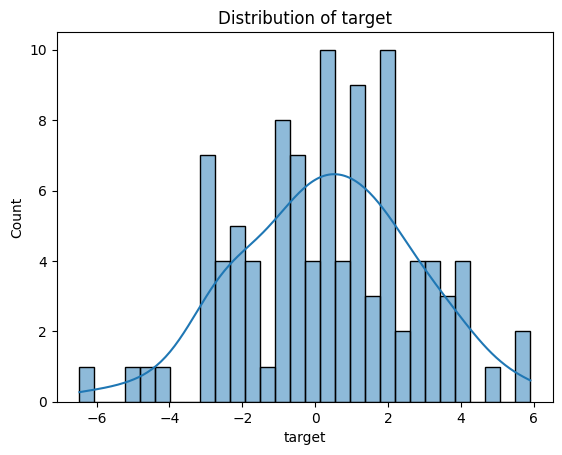

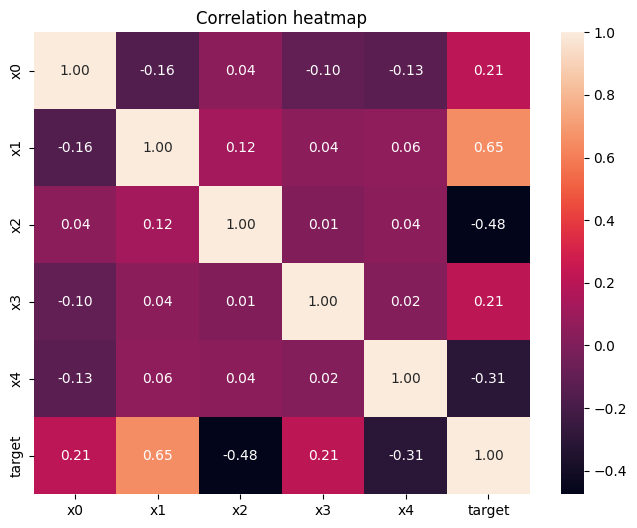

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.histplot(df["target"], bins=30, kde=True)
plt.title("Distribution of target")
plt.show()

corr = df.corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation heatmap")
plt.show()

## 7) Бонус: Iris dataset + простая модель

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


Class distribution:
target
0    50
1    50
2    50
Name: count, dtype: int64


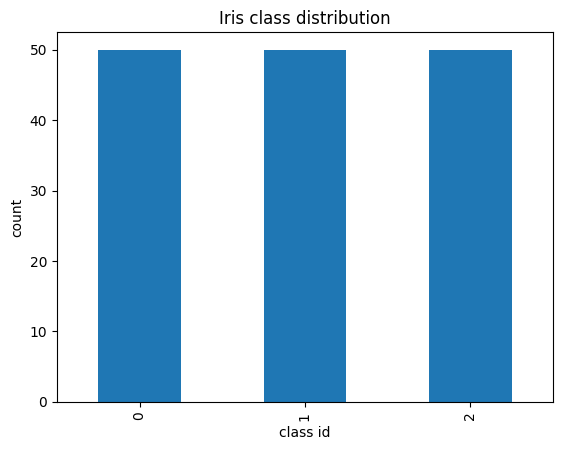

Accuracy: 0.9666666666666667

Confusion matrix:
 [[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [8]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

iris = load_iris(as_frame=True)
iris_df = iris.frame.copy()

display(iris_df.head())
print("Class distribution:")
print(iris_df["target"].value_counts())

plt.figure()
iris_df["target"].value_counts().sort_index().plot(kind="bar")
plt.title("Iris class distribution")
plt.xlabel("class id")
plt.ylabel("count")
plt.show()

X_iris = iris_df.drop(columns=["target"])
y_iris = iris_df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42, stratify=y_iris
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))